# Credit Card Fraud Detection: SMOTE vs Baseline Comparative Analysis

This notebook summarizes the complete Machine Learning experiment for credit card fraud detection using:

- Logistic Regression without SMOTE
- Logistic Regression with SMOTE
- Random Forest without SMOTE
- Random Forest with SMOTE

The goal is to understand how class imbalance handling affects different ML algorithms and why SMOTE improves some models more than others.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression",
        "Random Forest",
        "Random Forest"
    ],
    "SMOTE": [
        "Without SMOTE",
        "With SMOTE",
        "Without SMOTE",
        "With SMOTE"
    ],
    "Accuracy": [
        0.999157,
        0.974211,
        0.999596,
        0.999456
    ],
    "Precision": [
        0.828947,
        0.058027,
        0.941176,
        0.845361
    ],
    "Recall": [
        0.642857,
        0.918367,
        0.816327,
        0.836735
    ],
    "F1 Score": [
        0.724138,
        0.109157,
        0.874317,
        0.841026
    ],
    "False Positives": [
        13,
        1461,
        5,
        15
    ],
    "False Negatives": [
        35,
        8,
        18,
        16
    ],
    "True Positives": [
        63,
        90,
        80,
        82
    ],
    "True Negatives": [
        56851,
        55403,
        56859,
        56849
    ]
})

results

,Model,SMOTE,Accuracy,Precision,Recall,F1 Score,False Positives,False Negatives,True Positives,True Negatives
0,Logistic Regression,Without SMOTE,0.999157,0.828947,0.642857,0.724138,13,35,63,56851
1,Logistic Regression,With SMOTE,0.974211,0.058027,0.918367,0.109157,1461,8,90,55403
2,Random Forest,Without SMOTE,0.999596,0.941176,0.816327,0.874317,5,18,80,56859
3,Random Forest,With SMOTE,0.999456,0.845361,0.836735,0.841026,15,16,82,56849


# Evaluation Metrics Used

For fraud detection, accuracy alone is not sufficient because the dataset is highly imbalanced.

The key metrics used are:

| Metric | Meaning |
|---|---|
| Accuracy | Overall correct predictions |
| Precision | Out of predicted frauds, how many were actually fraud |
| Recall | Out of actual frauds, how many were detected |
| F1 Score | Balance between Precision and Recall |
| False Positive | Genuine transaction wrongly flagged as fraud |
| False Negative | Fraud transaction missed by the model |

In fraud detection, **False Negatives are highly risky** because they represent actual frauds that were not detected.

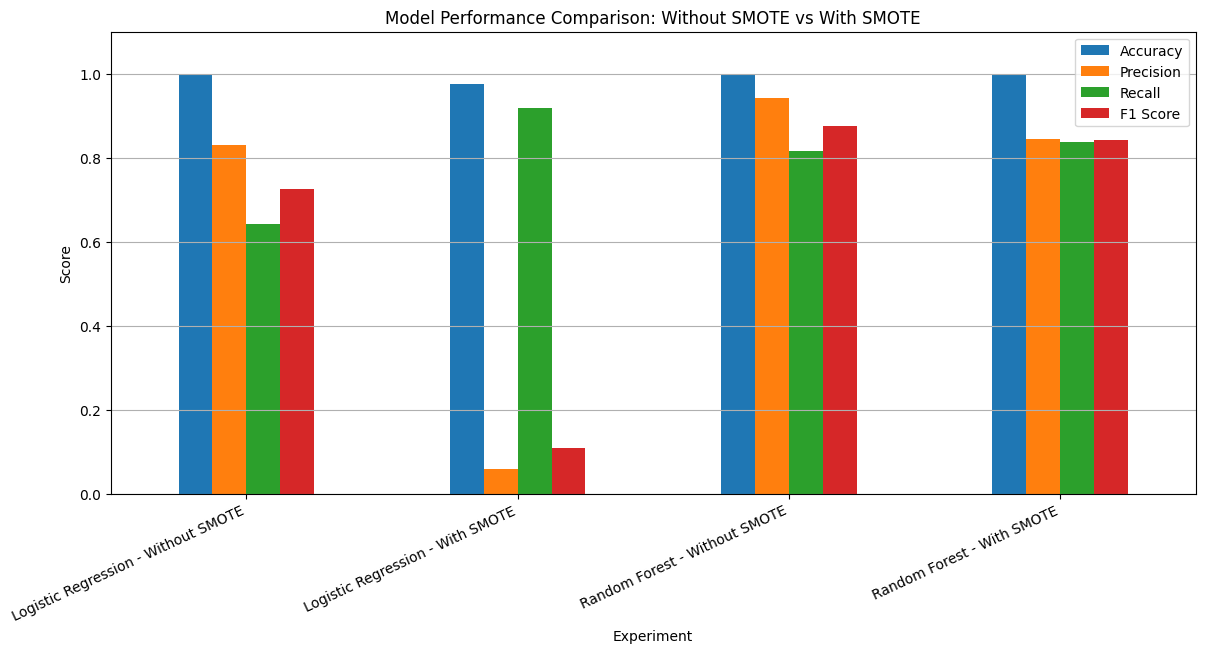

In [3]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

plot_df = results.copy()
plot_df["Experiment"] = plot_df["Model"] + " - " + plot_df["SMOTE"]

plot_df.set_index("Experiment")[metrics].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Model Performance Comparison: Without SMOTE vs With SMOTE")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y")
plt.show()

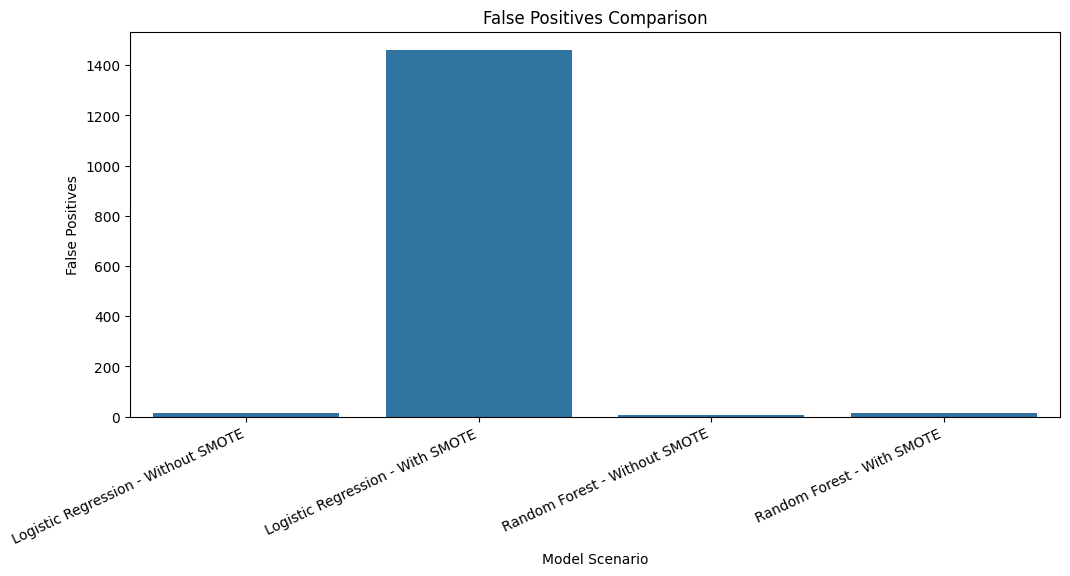

In [4]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=plot_df,
    x="Experiment",
    y="False Positives"
)

plt.title("False Positives Comparison")
plt.xlabel("Model Scenario")
plt.ylabel("False Positives")
plt.xticks(rotation=25, ha="right")
plt.show()

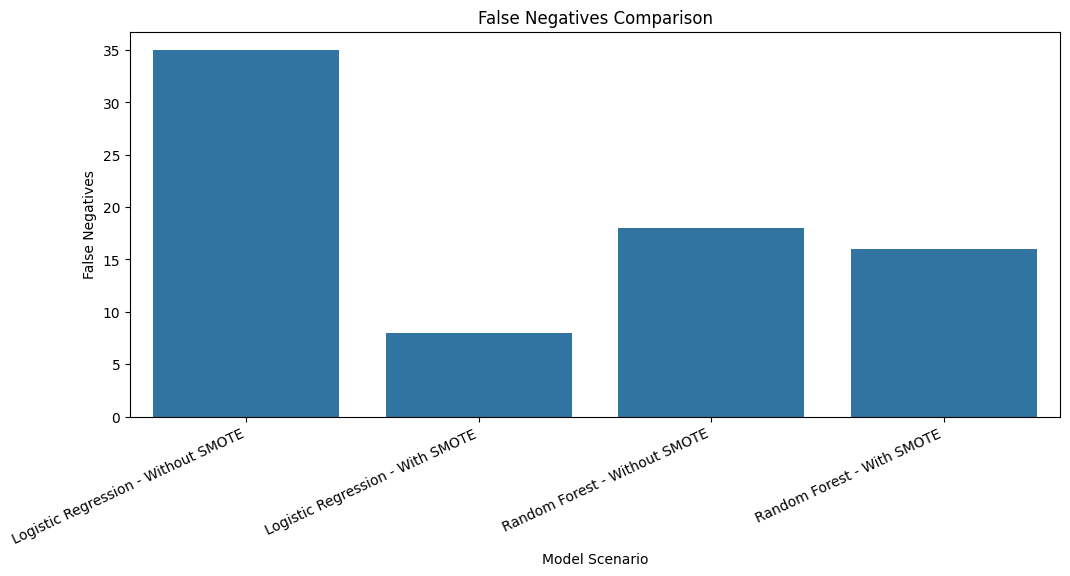

In [5]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=plot_df,
    x="Experiment",
    y="False Negatives"
)

plt.title("False Negatives Comparison")
plt.xlabel("Model Scenario")
plt.ylabel("False Negatives")
plt.xticks(rotation=25, ha="right")
plt.show()

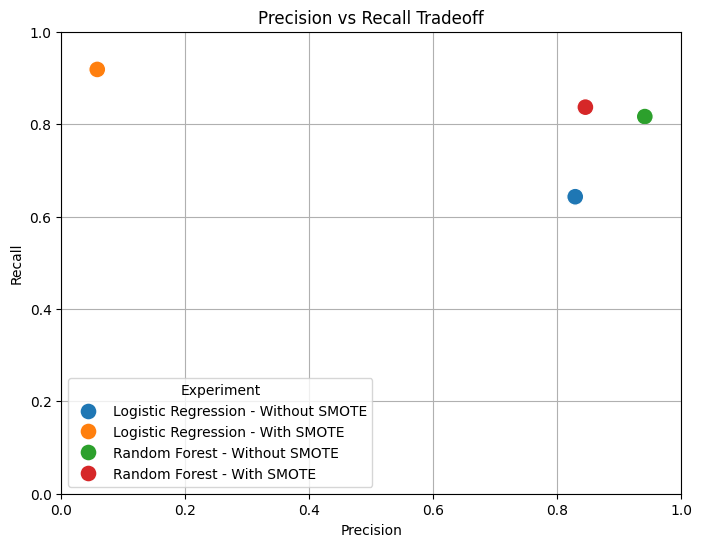

In [6]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=plot_df,
    x="Precision",
    y="Recall",
    hue="Experiment",
    s=150
)

plt.title("Precision vs Recall Tradeoff")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.show()

# Logistic Regression: How It Works

Logistic Regression is a linear classification algorithm used for binary classification problems.

In this project, it predicts:

- 0 = Non-Fraud
- 1 = Fraud

Logistic Regression estimates the probability that a transaction belongs to the fraud class.

The main equation is:

```text
p = 1 / (1 + e^(-z))

where:

z = β0 + β1x1 + β2x2 + ... + βnxn

If the predicted probability is greater than a threshold, usually 0.5, the transaction is classified as fraud.

Logistic Regression works well as a baseline because it is simple, fast, and interpretable.

However, it can struggle when the dataset is highly imbalanced because it may become biased toward the majority class.


##Logistic Regression Code Reference:-

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


# Random Forest: How It Works

Random Forest is an ensemble learning algorithm made up of multiple decision trees.

Each tree is trained on a random subset of the data and features.

For classification, each tree gives a prediction, and the final prediction is decided by majority voting.

```text
Final Prediction = Majority Vote of All Trees


Example:

If 100 trees are used:

85 trees predict Non-Fraud
15 trees predict Fraud

Final prediction = Non-Fraud

Random Forest is powerful because it can capture nonlinear relationships and complex feature interactions.

Unlike Logistic Regression, it is not limited to a linear decision boundary.

This is one reason Random Forest performed strongly even without SMOTE in this project.


---

##Random Forest Code Reference

```python
random_forest_code = """
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
"""

# Logistic Regression: Technical Explanation

Logistic Regression is a supervised Machine Learning algorithm used for binary classification problems.

In this project, the target variable has two classes:

| Class | Meaning   |
| ----- | --------- |
| 0     | Non-Fraud |
| 1     | Fraud     |

Although the name contains “regression”, Logistic Regression is used for classification. It predicts the probability that a transaction belongs to the fraud class.

---

## Mathematical Form

Logistic Regression first calculates a linear combination of input features:

```text
z = β0 + β1x1 + β2x2 + β3x3 + ... + βnxn
```

Where:

| Symbol          | Meaning                                          |
| --------------- | ------------------------------------------------ |
| z               | Linear score                                     |
| β0              | Intercept / bias term                            |
| β1, β2, ..., βn | Model coefficients                               |
| x1, x2, ..., xn | Input features such as Time, V1, V2, ..., Amount |

Then this linear score is passed through the sigmoid function:

```text
p = 1 / (1 + e^(-z))
```

The sigmoid function converts any real number into a probability between 0 and 1.

So the model output becomes:

```text
p = Probability that transaction is fraud
```

Usually:

| Probability | Prediction |
| ----------- | ---------- |
| p < 0.5     | Non-Fraud  |
| p ≥ 0.5     | Fraud      |

---

## Why Logistic Regression Was Used

Logistic Regression is useful as a baseline model because:

* it is simple and fast
* it is easy to interpret
* it provides probability-based outputs
* it works well for binary classification
* it helps reveal the impact of class imbalance clearly

---

## Limitation in This Project

Logistic Regression creates a mostly linear decision boundary.

In a highly imbalanced fraud dataset, the model sees many more non-fraud transactions than fraud transactions.

Before SMOTE, the training data had:

| Class     |  Count |
| --------- | -----: |
| Non-Fraud | 227451 |
| Fraud     |    394 |

Because fraud samples are rare, Logistic Regression tends to learn the majority class more strongly.

This is why the model without SMOTE had:

| Metric          |  Value |
| --------------- | -----: |
| Precision       | 82.89% |
| Recall          | 64.29% |
| False Negatives |     35 |

The model was conservative in predicting fraud. It avoided false alarms reasonably well, but missed many actual fraud cases.

---

# Logistic Regression Code Used

```python
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

## Code Explanation

```python
LogisticRegression(max_iter=1000)
```

creates the Logistic Regression model.

`max_iter=1000` allows the optimization algorithm enough iterations to converge.

```python
model.fit(X_train, y_train)
```

trains the model by learning coefficients for each feature.

```python
model.predict(X_test)
```

uses the learned coefficients to classify unseen test transactions as fraud or non-fraud.

---

# Random Forest: Technical Explanation

Random Forest is an ensemble learning algorithm based on multiple Decision Trees.

Instead of relying on a single tree, Random Forest builds many trees and combines their outputs to make a final prediction.

In this project, Random Forest is used for binary classification:

| Class | Meaning   |
| ----- | --------- |
| 0     | Non-Fraud |
| 1     | Fraud     |

---

## How a Decision Tree Works

A Decision Tree splits the data based on feature conditions.

Example:

```text
If V14 <= threshold:
    go left
else:
    go right
```

At each split, the tree tries to separate fraud and non-fraud transactions as well as possible.

The splitting is usually based on impurity measures such as:

```text
Gini Impurity
```

or:

```text
Entropy
```

For Gini Impurity:

```text
Gini = 1 - Σ(p_i)^2
```

Where:

| Symbol | Meaning                         |
| ------ | ------------------------------- |
| p_i    | Proportion of class i in a node |

A pure node has mostly one class and has low impurity.

---

## How Random Forest Improves Decision Trees

A single Decision Tree can overfit.

Random Forest reduces this problem by using two main techniques:

## 1. Bagging

Random Forest trains each tree on a random sample of the training data.

This is called bootstrap sampling.

Each tree sees a slightly different version of the dataset.

## 2. Random Feature Selection

At each split, the tree does not consider all features.

It considers only a random subset of features.

This creates diversity among trees.

---

## Final Prediction

For classification, Random Forest uses majority voting.

Example:

If 100 trees are trained:

| Prediction | Number of Trees |
| ---------- | --------------: |
| Non-Fraud  |              85 |
| Fraud      |              15 |

Final prediction:

```text
Non-Fraud
```

If most trees vote fraud, the final prediction becomes fraud.

---

## Why Random Forest Worked Well Here

Random Forest can capture:

* nonlinear relationships
* feature interactions
* complex decision boundaries
* rare fraud patterns
* localized patterns in tabular data

Unlike Logistic Regression, it does not assume a linear relationship between features and class probability.

That is why Random Forest performed strongly even without SMOTE.

Without SMOTE, Random Forest achieved:

| Metric          |  Value |
| --------------- | -----: |
| Accuracy        | 99.96% |
| Precision       | 94.12% |
| Recall          | 81.63% |
| F1 Score        | 87.43% |
| False Positives |      5 |
| False Negatives |     18 |

This shows that Random Forest learned fraud patterns better than Logistic Regression even without oversampling.

---

# Random Forest Code Used

```python
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
```

## Code Explanation

```python
n_estimators=100
```

means the Random Forest builds 100 Decision Trees.

```python
random_state=42
```

ensures the result is reproducible.

```python
n_jobs=-1
```

uses all available CPU cores for faster training.

```python
rf_model.fit(X_train, y_train)
```

trains all trees on different random samples and random feature subsets.

```python
rf_model.predict(X_test)
```

uses majority voting across all trees to classify unseen transactions.

---

# SMOTE: Technical Explanation

SMOTE stands for:

```text
Synthetic Minority Oversampling Technique
```

It is used to handle class imbalance by generating synthetic samples for the minority class.

In this project:

| Class          | Meaning   |
| -------------- | --------- |
| Majority Class | Non-Fraud |
| Minority Class | Fraud     |

Before SMOTE, the training data was:

| Class     |  Count |
| --------- | -----: |
| Non-Fraud | 227451 |
| Fraud     |    394 |

After SMOTE:

| Class     |  Count |
| --------- | -----: |
| Non-Fraud | 227451 |
| Fraud     | 227451 |

SMOTE created synthetic fraud transactions until the fraud class became equal to the non-fraud class.

---

## Mathematical Working of SMOTE

SMOTE does not simply duplicate fraud rows.

Instead, it creates new synthetic fraud samples between existing fraud samples.

The formula is:

```text
x_new = x_i + λ × (x_neighbor - x_i)
```

Where:

| Symbol     | Meaning                            |
| ---------- | ---------------------------------- |
| x_i        | Existing fraud sample              |
| x_neighbor | One of the nearest fraud neighbors |
| λ          | Random value between 0 and 1       |
| x_new      | New synthetic fraud sample         |

---

## Simple Example

Suppose one fraud sample has a feature value:

```text
x_i = 10
```

and a nearby fraud sample has:

```text
x_neighbor = 16
```

If:

```text
λ = 0.5
```

Then:

```text
x_new = 10 + 0.5 × (16 - 10)
x_new = 13
```

So the new fraud point is created between two existing fraud points.

In the actual dataset, this process happens across all feature columns:

```text
Time, V1, V2, V3, ..., V28, Amount
```

So SMOTE creates complete synthetic transaction rows, not just one feature value.

---

## Backend Logic of SMOTE

Internally, SMOTE performs these steps:

1. Identifies the minority class.
2. Selects a minority class sample.
3. Finds its nearest minority class neighbors using distance-based similarity.
4. Randomly selects one of those neighbors.
5. Calculates the difference between the selected sample and the neighbor.
6. Multiplies the difference by a random value between 0 and 1.
7. Adds this value to the original sample.
8. Creates a synthetic minority sample.
9. Repeats the process until the minority class reaches the required size.

In simple terms:

```text
SMOTE learns where fraud samples exist in feature space and creates new synthetic fraud points between similar fraud transactions.
```

---

# SMOTE Code Used

```python
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
```

## Code Explanation

```python
smote = SMOTE(random_state=42)
```

creates the SMOTE object.

`random_state=42` ensures the synthetic samples are reproducible.

```python
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
```

applies SMOTE to the training data.

This line performs both:

| Operation | Meaning                                               |
| --------- | ----------------------------------------------------- |
| fit       | Learns minority class structure and nearest neighbors |
| resample  | Generates synthetic fraud samples                     |

---

## Important: Why SMOTE Is Applied Only on Training Data

SMOTE must be applied only after train-test split.

Correct workflow:

```text
Train-Test Split → Scaling → SMOTE on Training Data → Model Training → Testing
```

Incorrect workflow:

```text
SMOTE on Full Dataset → Train-Test Split
```

Applying SMOTE before splitting causes data leakage.

This means synthetic samples may be created using information from transactions that later appear in the test set.

That would make model performance look better than it really is.

In this project, SMOTE was correctly applied only to:

```text
X_train and y_train
```

The test set remained untouched and realistic.

---

# Why SMOTE Helped Logistic Regression

Logistic Regression is a linear model.

Before SMOTE, it trained on a highly imbalanced dataset:

| Class     |  Count |
| --------- | -----: |
| Non-Fraud | 227451 |
| Fraud     |    394 |

Because fraud examples were extremely rare, the model learned the majority non-fraud class more strongly.

Without SMOTE:

| Metric          |  Value |
| --------------- | -----: |
| Accuracy        | 99.91% |
| Precision       | 82.89% |
| Recall          | 64.29% |
| F1 Score        | 72.41% |
| False Positives |     13 |
| False Negatives |     35 |

After SMOTE, Logistic Regression trained on a balanced dataset:

| Class     |  Count |
| --------- | -----: |
| Non-Fraud | 227451 |
| Fraud     | 227451 |

This changed the learned decision boundary.

The model became more sensitive to the fraud class.

With SMOTE:

| Metric          |  Value |
| --------------- | -----: |
| Accuracy        | 97.42% |
| Precision       |  5.80% |
| Recall          | 91.84% |
| F1 Score        | 10.92% |
| False Positives |   1461 |
| False Negatives |      8 |

The major benefit was:

```text
Recall increased from 64.29% to 91.84%
```

and:

```text
False Negatives reduced from 35 to 8
```

This means Logistic Regression detected many more fraud transactions after SMOTE.

However, the model also became too aggressive in predicting fraud.

This caused:

```text
False Positives increased from 13 to 1461
```

and:

```text
Precision dropped from 82.89% to 5.80%
```

So SMOTE helped Logistic Regression catch fraud, but it severely increased false alarms.

---

# Why SMOTE Did Not Improve Random Forest Much

Random Forest already performed strongly without SMOTE.

Without SMOTE:

| Metric          |  Value |
| --------------- | -----: |
| Accuracy        | 99.96% |
| Precision       | 94.12% |
| Recall          | 81.63% |
| F1 Score        | 87.43% |
| False Positives |      5 |
| False Negatives |     18 |

This means Random Forest was already able to detect many fraud cases while keeping false alarms very low.

After applying SMOTE:

| Metric          |  Value |
| --------------- | -----: |
| Accuracy        | 99.95% |
| Precision       | 84.54% |
| Recall          | 83.67% |
| F1 Score        | 84.10% |
| False Positives |     15 |
| False Negatives |     16 |

SMOTE improved Recall only slightly:

```text
81.63% → 83.67%
```

and reduced False Negatives only slightly:

```text
18 → 16
```

But Precision decreased:

```text
94.12% → 84.54%
```

and False Positives increased:

```text
5 → 15
```

This means SMOTE made Random Forest slightly more sensitive to fraud, but the benefit was small.

The cost was a higher false alarm rate.

---

# Why This Happened Technically

Random Forest does not depend on one linear boundary like Logistic Regression.

It builds many nonlinear decision regions using multiple trees.

Because of this, it can naturally capture small fraud-specific patterns even when the fraud class is rare.

SMOTE adds synthetic samples between existing fraud samples.

For Logistic Regression, this can help because the model needs more balanced data to shift its linear decision boundary.

For Random Forest, the synthetic fraud points may not add much new information because the model already captures fraud regions well.

In some cases, synthetic samples can slightly blur the boundary between fraud and non-fraud regions.

This may increase false positives.

That is why Random Forest with SMOTE did not outperform Random Forest without SMOTE overall.

---

# Full Model Comparison

| Metric          | Logistic Regression Without SMOTE | Logistic Regression With SMOTE | Random Forest Without SMOTE | Random Forest With SMOTE |
| --------------- | --------------------------------: | -----------------------------: | --------------------------: | -----------------------: |
| Accuracy        |                            99.91% |                         97.42% |                      99.96% |                   99.95% |
| Precision       |                            82.89% |                          5.80% |                      94.12% |                   84.54% |
| Recall          |                            64.29% |                         91.84% |                      81.63% |                   83.67% |
| F1 Score        |                            72.41% |                         10.92% |                      87.43% |                   84.10% |
| False Positives |                                13 |                           1461 |                           5 |                       15 |
| False Negatives |                                35 |                              8 |                          18 |                       16 |

---

# Best Model by Objective

| Objective              | Best Model                     |
| ---------------------- | ------------------------------ |
| Highest Accuracy       | Random Forest Without SMOTE    |
| Highest Precision      | Random Forest Without SMOTE    |
| Highest Recall         | Logistic Regression With SMOTE |
| Highest F1 Score       | Random Forest Without SMOTE    |
| Lowest False Positives | Random Forest Without SMOTE    |
| Lowest False Negatives | Logistic Regression With SMOTE |

---

# Final Findings

This project shows that SMOTE is not automatically better for every model.

SMOTE helped Logistic Regression strongly because Logistic Regression was more affected by class imbalance.

It increased fraud detection sensitivity and reduced missed frauds.

However, this came at the cost of many false positives.

Random Forest performed best overall without SMOTE.

It achieved the best balance between Precision, Recall, F1 Score, and false alarm control.

Random Forest with SMOTE slightly improved Recall, but the improvement was not large enough to justify the decrease in Precision and F1 Score.

---

# Final Conclusion

The strongest balanced model in this experiment is:

```text
Random Forest Without SMOTE
```

because it achieved:

* highest Precision
* highest F1 Score
* very high Recall
* very low False Positives
* strong overall fraud detection balance

However, if the business goal is to catch the maximum number of fraud transactions, even at the cost of more false alarms, then:

```text
Logistic Regression With SMOTE
```

is useful because it achieved the highest Recall and lowest False Negatives.

The main learning from this project is:

```text
SMOTE is powerful, but model-dependent.
```

It improved Logistic Regression significantly in terms of Recall, but it did not make Random Forest better overall.

This highlights the real-world fraud detection tradeoff:

```text
Catching more frauds vs reducing false alarms
```

A practical production system should therefore consider:

* model selection
* threshold tuning
* cost-sensitive learning
* precision-recall tradeoff
* business cost of false positives and false negatives
* monitoring model behavior over time
